VAL  MAE: 0.15255674175332265  MSE: 0.03651880935067381
TEST MAE: 0.15228550157823473  MSE: 0.036427154892930934


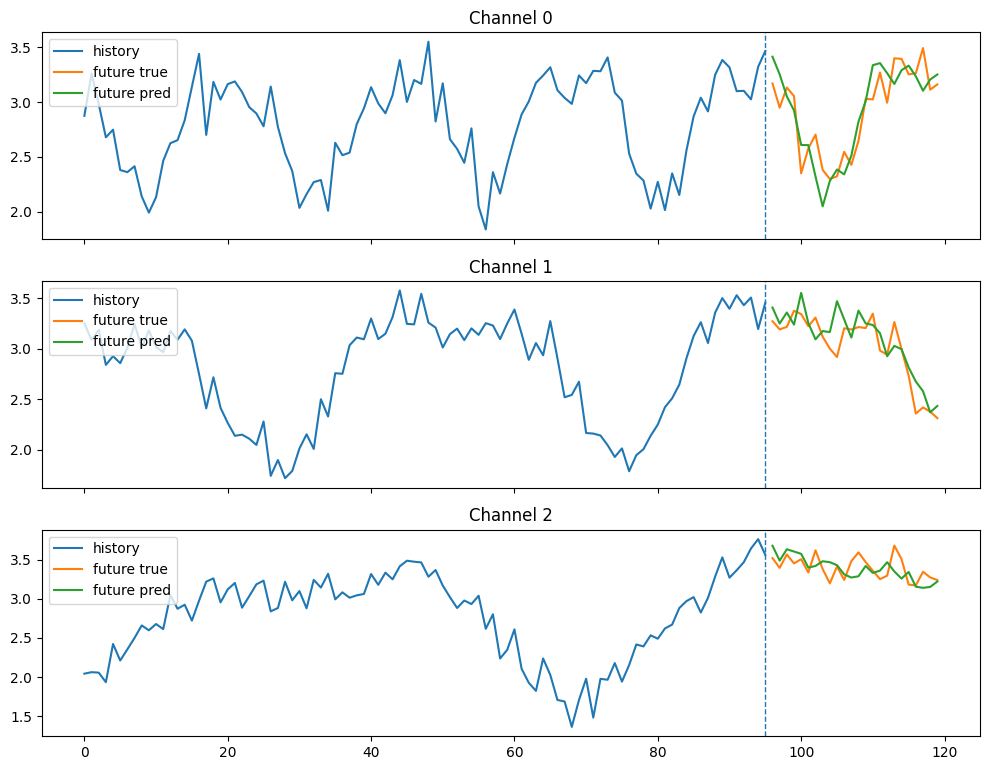

In [1]:
# LTBoost-style demo on a synthetic multivariate time series
# - Sliding-window dataset (Tin -> Tout)
# - Drift normalization (subtract last observed value in the input window)
# - Per-(timestep, channel) standardization across training samples
# - Base model: linear regression (multi-output)
# - Boosting model: per-channel gradient boosting on residuals (multi-output)
# - Final: Y = Y_lin + Y_boost, then inverse normalization

from __future__ import annotations

import numpy as np

from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

import matplotlib.pyplot as plt


# ----------------------------
# Utilities: windowing
# ----------------------------
def make_windows(series: np.ndarray, tin: int, tout: int):
    """
    series: (T, C)
    returns:
      X: (N, tin, C)
      Y: (N, tout, C)
    """
    T, C = series.shape
    N = T - tin - tout + 1
    if N <= 0:
        raise ValueError("Time series too short for given tin/tout.")
    X = np.zeros((N, tin, C), dtype=np.float64)
    Y = np.zeros((N, tout, C), dtype=np.float64)
    for i in range(N):
        X[i] = series[i : i + tin]
        Y[i] = series[i + tin : i + tin + tout]
    return X, Y


# ----------------------------
# LTBoost Normalizer (paper-style)
# ----------------------------
class LTBoostNormalizer:
    """
    Implements:
      1) Drift normalization: x_tilde[t] = x[t] - x_last (per-sample, per-channel)
      2) Per-(timestep, channel) standardization across training samples:
         x_hat = (x_tilde - mu[t,c]) / (std[t,c] + eps)

    We compute stats for both X and Y drift-normalized tensors, separately.
    """

    def __init__(self, eps: float = 1e-6):
        self.eps = float(eps)
        self.mu_x = None  # (tin, C)
        self.std_x = None  # (tin, C)
        self.mu_y = None  # (tout, C)
        self.std_y = None  # (tout, C)

    @staticmethod
    def _drift_norm_X(X: np.ndarray):
        # X: (N, tin, C) -> subtract last value in the input window (per N,C)
        last = X[:, -1:, :]                 # (N, 1, C)
        return X - last, last.squeeze(1)    # X_tilde, last_value (N, C)

    @staticmethod
    def _drift_norm_Y(Y: np.ndarray, x_last: np.ndarray):
        # Y: (N, tout, C), x_last: (N, C) from input window
        return Y - x_last[:, None, :]       # broadcast to (N, 1, C)

    def fit(self, X: np.ndarray, Y: np.ndarray):
        X_tilde, x_last = self._drift_norm_X(X)
        Y_tilde = self._drift_norm_Y(Y, x_last)

        # Stats across samples (axis=0) for each timestep and channel
        self.mu_x = X_tilde.mean(axis=0)               # (tin, C)
        self.std_x = X_tilde.std(axis=0) + self.eps    # (tin, C)

        self.mu_y = Y_tilde.mean(axis=0)               # (tout, C)
        self.std_y = Y_tilde.std(axis=0) + self.eps    # (tout, C)
        return self

    def transform(self, X: np.ndarray, Y: np.ndarray | None = None):
        X_tilde, x_last = self._drift_norm_X(X)
        Xn = (X_tilde - self.mu_x[None, :, :]) / self.std_x[None, :, :]

        if Y is None:
            return Xn, x_last

        Y_tilde = self._drift_norm_Y(Y, x_last)
        Yn = (Y_tilde - self.mu_y[None, :, :]) / self.std_y[None, :, :]
        return Xn, Yn, x_last

    def inverse_Y(self, Y_norm: np.ndarray, x_last: np.ndarray):
        """
        Y_norm: (N, tout, C) in normalized space
        x_last: (N, C) last input values (for undoing drift)
        """
        Y_tilde = Y_norm * self.std_y[None, :, :] + self.mu_y[None, :, :]
        Y = Y_tilde + x_last[:, None, :]
        return Y


# ----------------------------
# LTBoost model
# ----------------------------
class LTBoost:
    """
    Base: multi-output Ridge on flattened X -> flattened Y
    Boost: per-channel MultiOutputRegressor(HistGradientBoostingRegressor)
           trained on residuals (Y_norm - Y_lin_norm)
    """

    def __init__(
        self,
        tin: int,
        tout: int,
        n_channels: int,
        ridge_alpha: float = 1.0,
        gbdt_max_depth: int = 6,
        gbdt_learning_rate: float = 0.05,
        gbdt_max_iter: int = 300,
        random_state: int = 0,
    ):
        self.tin = int(tin)
        self.tout = int(tout)
        self.C = int(n_channels)

        self.norm = LTBoostNormalizer(eps=1e-6)

        self.base = Ridge(alpha=ridge_alpha, random_state=random_state)

        self.boosters = []
        for _c in range(self.C):
            est = HistGradientBoostingRegressor(
                max_depth=gbdt_max_depth,
                learning_rate=gbdt_learning_rate,
                max_iter=gbdt_max_iter,
                random_state=random_state,
            )
            self.boosters.append(MultiOutputRegressor(est))

    def _flatX(self, Xn: np.ndarray) -> np.ndarray:
        # (N, tin, C) -> (N, tin*C)
        return Xn.reshape(Xn.shape[0], -1)

    def _flatY(self, Yn: np.ndarray) -> np.ndarray:
        # (N, tout, C) -> (N, tout*C)
        return Yn.reshape(Yn.shape[0], -1)

    def _unflatY(self, Yf: np.ndarray) -> np.ndarray:
        # (N, tout*C) -> (N, tout, C)
        return Yf.reshape(Yf.shape[0], self.tout, self.C)

    def fit(self, X: np.ndarray, Y: np.ndarray):
        """
        X: (N, tin, C), Y: (N, tout, C)
        """
        self.norm.fit(X, Y)
        Xn, Yn, x_last = self.norm.transform(X, Y)

        Xf = self._flatX(Xn)
        Yf = self._flatY(Yn)

        # 1) Base linear model
        self.base.fit(Xf, Yf)
        Ylin_f = self.base.predict(Xf)
        Ylin = self._unflatY(Ylin_f)

        # 2) Residuals in normalized space
        Yres = Yn - Ylin

        # 3) Per-channel boosting on residuals
        for c in range(self.C):
            # Inputs can be the same flattened Xn; targets are residual horizon vector for channel c: (N, tout)
            self.boosters[c].fit(Xf, Yres[:, :, c])

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        X: (N, tin, C) -> Y_pred: (N, tout, C) in original scale
        """
        Xn, x_last = self.norm.transform(X, Y=None)
        Xf = self._flatX(Xn)

        # Base
        Ylin_f = self.base.predict(Xf)
        Ylin = self._unflatY(Ylin_f)

        # Boost residuals
        Yboost = np.zeros_like(Ylin)
        for c in range(self.C):
            Yboost[:, :, c] = self.boosters[c].predict(Xf)

        Yfinal_norm = Ylin + Yboost
        Yfinal = self.norm.inverse_Y(Yfinal_norm, x_last)
        return Yfinal


# ----------------------------
# Demo: synthetic data
# ----------------------------
def make_synthetic_series(T: int = 1500, C: int = 3, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    t = np.arange(T, dtype=np.float64)

    series = np.zeros((T, C), dtype=np.float64)
    # Shared trend
    trend = 0.002 * t
    # Different seasonalities per channel
    for c in range(C):
        period = 24 * (c + 1)
        season = 0.5 * np.sin(2 * np.pi * t / period) + 0.2 * np.cos(2 * np.pi * t / (period * 0.5))
        # Mild cross-channel interaction
        interaction = 0.0
        if c > 0:
            interaction = 0.15 * np.sin(2 * np.pi * t / (24 * c))  # something correlated-ish
        noise = 0.15 * rng.standard_normal(T)
        series[:, c] = (1.0 + 0.2 * c) * season + trend + interaction + noise
    return series


def train_test_split_windows(X, Y, train_ratio=0.7, val_ratio=0.1):
    N = X.shape[0]
    n_train = int(N * train_ratio)
    n_val = int(N * val_ratio)
    Xtr, Ytr = X[:n_train], Y[:n_train]
    Xva, Yva = X[n_train : n_train + n_val], Y[n_train : n_train + n_val]
    Xte, Yte = X[n_train + n_val :], Y[n_train + n_val :]
    return (Xtr, Ytr), (Xva, Yva), (Xte, Yte)


def mae(a, b):
    return np.mean(np.abs(a - b))


def mse(a, b):
    return np.mean((a - b) ** 2)


if __name__ == "__main__":
    # Settings
    T = 1800
    C = 3
    tin = 96
    tout = 24

    series = make_synthetic_series(T=T, C=C, seed=1)
    X, Y = make_windows(series, tin=tin, tout=tout)
    (Xtr, Ytr), (Xva, Yva), (Xte, Yte) = train_test_split_windows(X, Y, train_ratio=0.7, val_ratio=0.1)

    model = LTBoost(
        tin=tin,
        tout=tout,
        n_channels=C,
        ridge_alpha=1.0,
        gbdt_max_depth=6,
        gbdt_learning_rate=0.05,
        gbdt_max_iter=300,
        random_state=0,
    )

    model.fit(Xtr, Ytr)

    # Evaluate
    Yhat_va = model.predict(Xva)
    Yhat_te = model.predict(Xte)

    print("VAL  MAE:", mae(Yhat_va, Yva), " MSE:", mse(Yhat_va, Yva))
    print("TEST MAE:", mae(Yhat_te, Yte), " MSE:", mse(Yhat_te, Yte))

    # Plot one example window from test set
    idx = 10
    x_in = Xte[idx]          # (tin, C)
    y_true = Yte[idx]        # (tout, C)
    y_pred = Yhat_te[idx]    # (tout, C)

    t_in = np.arange(tin)
    t_out = np.arange(tin, tin + tout)

    fig, axes = plt.subplots(C, 1, figsize=(10, 2.6 * C), sharex=True)
    if C == 1:
        axes = [axes]

    for c in range(C):
        ax = axes[c]
        ax.plot(t_in, x_in[:, c], label="history")
        ax.plot(t_out, y_true[:, c], label="future true")
        ax.plot(t_out, y_pred[:, c], label="future pred")
        ax.axvline(tin - 1, linestyle="--", linewidth=1)
        ax.set_title(f"Channel {c}")
        ax.legend(loc="upper left")

    plt.tight_layout()
    plt.show()


In [1]:
!pip install xgboost lightgbm catboost

  Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
  Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl.metadata (17 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl (131.7 MB)
Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl (3.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 61.3 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [catboost]3/4 [catboost]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
